<a href="https://colab.research.google.com/github/pookiee777/-Reef-fisheries-data-pipeline-/blob/main/reef_fisheries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

In [ ]:
# Cell 2: Advanced Data Loading, Cleaning, and Feature Engineering (FIXED)
import pandas as pd
import numpy as np

# 1. Load the data without setting the index yet
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"
df = pd.read_csv(url)

# 2. PROPER DATETIME PARSING (The Fix)
# Combine the separate date columns into a single true Datetime object
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('datetime', inplace=True)

# Drop the old redundant time columns and the 'No' (row number) column
df.drop(['No', 'year', 'month', 'day', 'hour'], axis=1, inplace=True)

# 3. Rename target variable for clarity
df.rename(columns={'pm2.5': 'PM25'}, inplace=True)

# 4. Handle Missing Values (Linear Interpolation)
df['PM25'] = df['PM25'].interpolate(method='linear')
df.dropna(subset=['PM25'], inplace=True)

# 5. Handle Outliers (Capping / Winsorization)
upper_limit = df['PM25'].quantile(0.995)
df['PM25'] = np.where(df['PM25'] > upper_limit, upper_limit, df['PM25'])

# 6. Feature Engineering: Categorical Encoding
# Convert wind direction into numerical dummy variables
df = pd.get_dummies(df, columns=['cbwd'], prefix='wind_dir', drop_first=True)

# 7. Resample to Daily Data
daily_df = df.resample('D').mean()

print("\n--- Advanced Cleaning Summary ---")
print(f"Data shape after daily resampling: {daily_df.shape}")
print(f"Missing values remaining: {daily_df.isnull().sum().sum()}")

# Verify the index is now correct (should show daily dates from 2010 to 2014)
print("\nFirst few rows:")
display(daily_df.head())


--- Advanced Cleaning Summary ---
Data shape after daily resampling: (1825, 10)
Missing values remaining: 0

First few rows:


,PM25,DEWP,TEMP,PRES,Iws,Is,Ir,wind_dir_NW,wind_dir_SE,wind_dir_cv
datetime,,,,,,,,,,
2010-01-02,145.958333,-8.500000,-5.125000,1024.750000,24.860000,0.708333,0.0,0.000000,1.00,0.000000
2010-01-03,78.833333,-10.125000,-8.541667,1022.791667,70.937917,14.166667,0.0,0.166667,0.75,0.083333
2010-01-04,31.333333,-20.875000,-11.500000,1029.291667,111.160833,0.000000,0.0,1.000000,0.00,0.000000
2010-01-05,42.458333,-24.583333,-14.458333,1033.625000,56.920000,0.000000,0.0,0.583333,0.00,0.041667
2010-01-06,56.416667,-23.708333,-12.541667,1033.750000,18.511667,0.000000,0.0,0.416667,0.00,0.083333


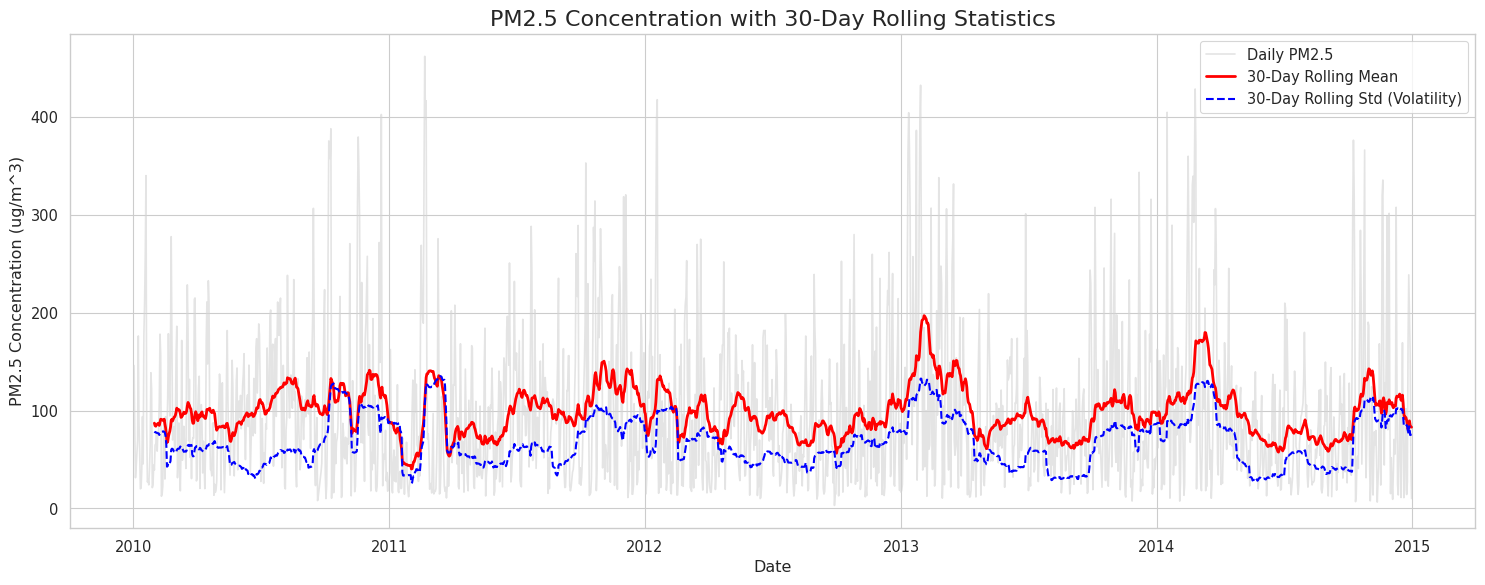

--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -16.1899
p-value: 0.0000
Conclusion: Data is STATIONARY (Reject the null hypothesis).
Action: Differencing (d=0) might be sufficient for ARIMA.
------------------------------------------


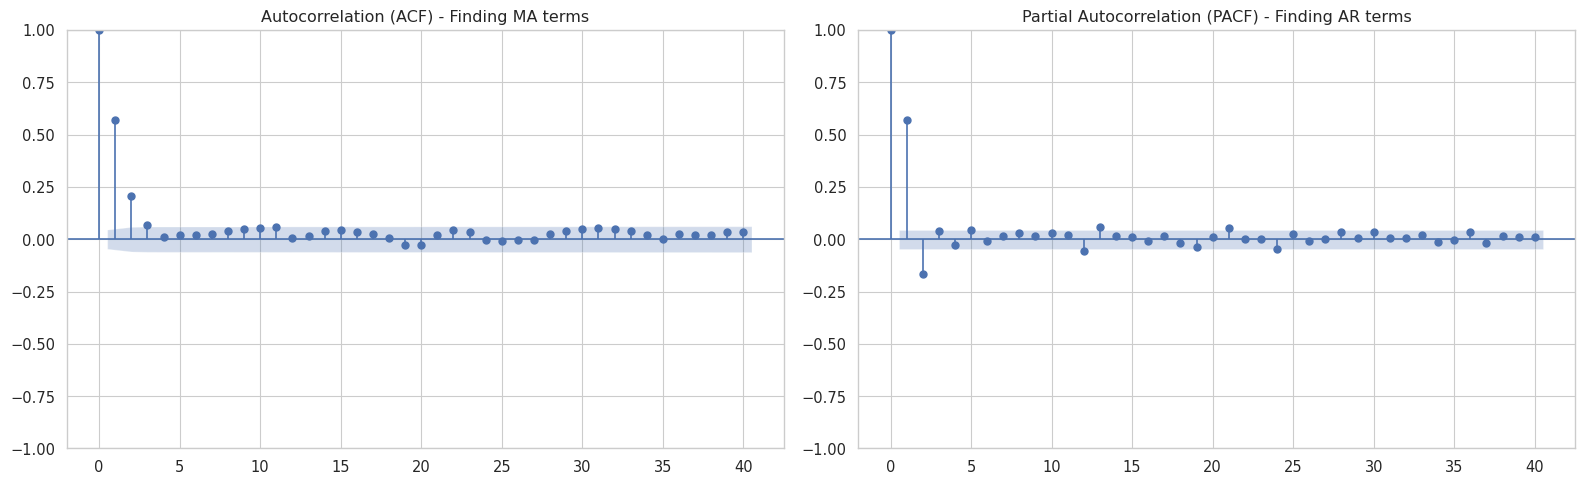

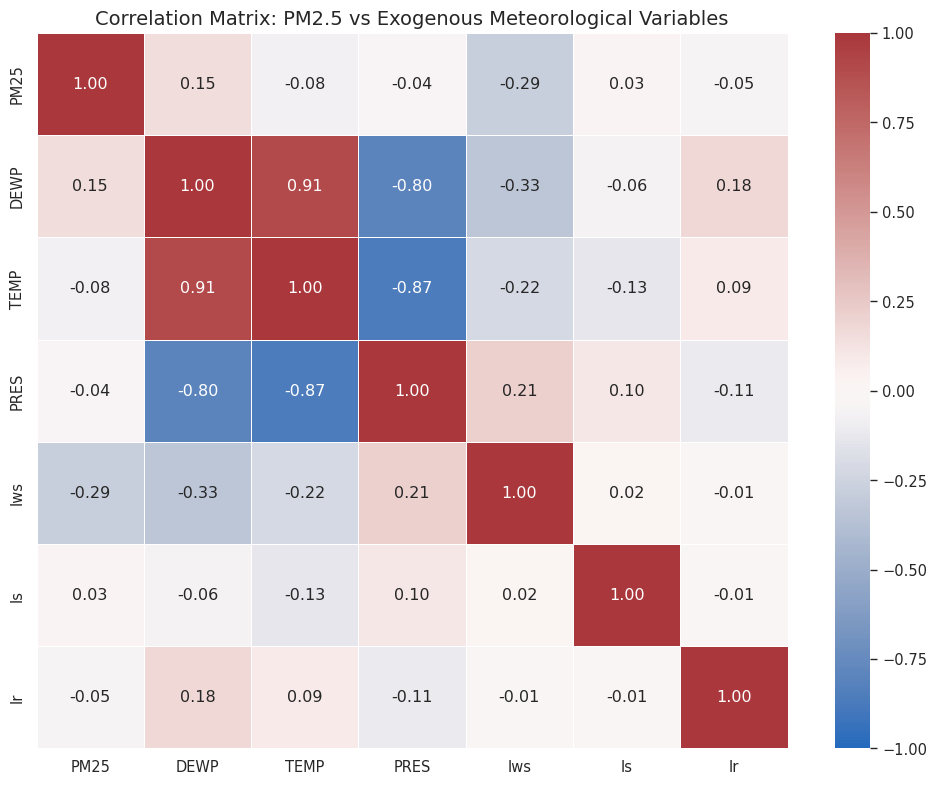

In [ ]:
# Cell 3: Advanced Exploratory Data Analysis (EDA) & Statistical Testing
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Set a clean, academic plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- 1. Volatility and Trend Analysis (Rolling Statistics) ---
plt.figure(figsize=(15, 6))
# Plot raw daily data lightly in the background
plt.plot(daily_df.index, daily_df['PM25'], color='lightgrey', label='Daily PM2.5', alpha=0.6)
# Overlay 30-day moving average and rolling standard deviation
plt.plot(daily_df.index, daily_df['PM25'].rolling(window=30).mean(), color='red', label='30-Day Rolling Mean', linewidth=2)
plt.plot(daily_df.index, daily_df['PM25'].rolling(window=30).std(), color='blue', label='30-Day Rolling Std (Volatility)', linewidth=1.5, linestyle='--')

plt.title('PM2.5 Concentration with 30-Day Rolling Statistics', fontsize=16)
plt.ylabel('PM2.5 Concentration (ug/m^3)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Stationarity Check (Augmented Dickey-Fuller Test) ---
# Time-series models like ARIMA require the data to be stationary (constant mean/variance)
print("--- Augmented Dickey-Fuller (ADF) Test ---")
adf_result = adfuller(daily_df['PM25'].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

if adf_result[1] <= 0.05:
    print("Conclusion: Data is STATIONARY (Reject the null hypothesis).")
    print("Action: Differencing (d=0) might be sufficient for ARIMA.")
else:
    print("Conclusion: Data is NON-STATIONARY (Fail to reject the null hypothesis).")
    print("Action: Differencing (d>0) is required for ARIMA.")
print("-" * 42)

# --- 3. Autocorrelation (ACF) and Partial Autocorrelation (PACF) ---
# This mathematically justifies our lag selection for models
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(daily_df['PM25'].dropna(), lags=40, ax=ax[0], title="Autocorrelation (ACF) - Finding MA terms")
plot_pacf(daily_df['PM25'].dropna(), lags=40, ax=ax[1], title="Partial Autocorrelation (PACF) - Finding AR terms")
plt.tight_layout()
plt.show()

# --- 4. Multivariate Correlation Analysis ---
# Analyzing the relationship between PM2.5 and meteorological factors
plt.figure(figsize=(10, 8))

# Select weather columns to see how they correlate with pollution
# DEWP: Dew Point, TEMP: Temperature, PRES: Pressure, Iws: Wind Speed, Is: Snow, Ir: Rain
corr_cols = ['PM25', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
existing_cols = [col for col in corr_cols if col in daily_df.columns]
corr_matrix = daily_df[existing_cols].corr()

# Plot heatmap using a diverging color palette
sns.heatmap(corr_matrix, annot=True, cmap='vlag', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: PM2.5 vs Exogenous Meteorological Variables', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# We will use the last 30 days for testing
test_size = 30
train_data = daily_df.iloc[:-test_size]
test_data = daily_df.iloc[-test_size:]

print(f"Training data: {len(train_data)} days")
print(f"Testing data: {len(test_data)} days")

# Helper function to create lag features for XGBoost (Supervised Learning framing)
def create_lag_features(data, lag=7):
    df_lagged = data.copy()
    for i in range(1, lag + 1):
        df_lagged[f'lag_{i}'] = df_lagged['PM25'].shift(i)
    df_lagged.dropna(inplace=True)
    return df_lagged

lagged_df = create_lag_features(daily_df, lag=7)

# Split lagged data
train_lagged = lagged_df.iloc[:-test_size]
test_lagged = lagged_df.iloc[-test_size:]

X_train, y_train = train_lagged.drop('PM25', axis=1), train_lagged['PM25']
X_test, y_test = test_lagged.drop('PM25', axis=1), test_lagged['PM25']

Training data: 1795 days
Testing data: 30 days


In [ ]:
# Fit ARIMA model (Order p=5, d=1, q=0 as a basic starting point)
# p: auto-regressive lags, d: differencing, q: moving average
arima_model = ARIMA(train_data['PM25'], order=(5, 1, 0))
arima_result = arima_model.fit()

# Predict on test set
arima_predictions = arima_result.forecast(steps=test_size)

# Calculate Error
arima_rmse = np.sqrt(mean_squared_error(test_data['PM25'], arima_predictions))
arima_mae = mean_absolute_error(test_data['PM25'], arima_predictions)

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAE: {arima_mae:.2f}")


ARIMA RMSE: 77.32
ARIMA MAE: 63.57


In [ ]:
# Fit XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

# Predict on test set
xgb_predictions = xgb_model.predict(X_test)

# Calculate Error
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print(f"XGBoost RMSE: {xgb_rmse:.2f}")
print(f"XGBoost MAE: {xgb_mae:.2f}")


XGBoost RMSE: 38.87
XGBoost MAE: 25.78


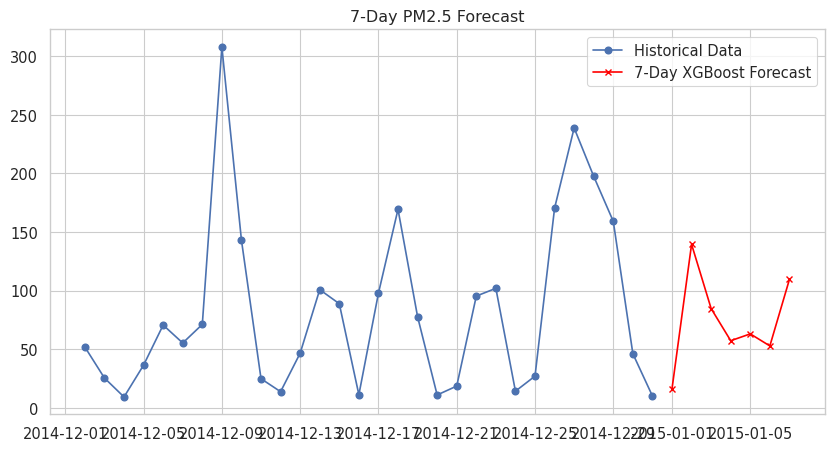

In [ ]:
# Recursive 7-day forecast using the trained XGBoost model
# We start with the last 7 days of our dataset as the initial input
last_known_lags = lagged_df.iloc[-1].drop('PM25').values.reshape(1, -1)
future_forecast = []

current_lags = last_known_lags.copy()

for _ in range(7):
    # Predict next day
    next_day_pred = xgb_model.predict(current_lags)[0]
    future_forecast.append(next_day_pred)

    # Update lags: shift everything right, insert new prediction at lag_1
    current_lags = np.roll(current_lags, shift=1)
    current_lags[0, 0] = next_day_pred

# Plot results
future_dates = pd.date_range(start=daily_df.index[-1] + pd.Timedelta(days=1), periods=7)

plt.figure(figsize=(10, 5))
plt.plot(daily_df.index[-30:], daily_df['PM25'].iloc[-30:], label='Historical Data', marker='o')
plt.plot(future_dates, future_forecast, label='7-Day XGBoost Forecast', color='red', marker='x')
plt.title('7-Day PM2.5 Forecast')
plt.legend()
plt.show()
